In [482]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1
Загрузите данные из csv-файла (comma separated values, разделитель – запятая) с именем, ”№_Имя_города.csv”, где № - номер Вашего варианта, в двумерный массив (или список).

In [483]:
data = pd.read_csv('./data/lab_3_data.csv') 
months = data.iloc(0)
data = data[data['средняя'] != 999.9]
data

,Год,янв,фев,мар,апр,май,июн,июл,авг,сен,окт,ноя,дек,средняя
1,1818,-13.0,-20.2,-4.5,0.6,5.7,13.9,14.2,14.3,9.0,-2.0,-12.2,-9.7,-0.3
2,1819,-11.0,-17.3,-6.9,-2.9,3.7,15.6,15.8,12.8,9.6,2.1,-12.5,-17.2,-0.7
3,1820,-20.2,-17.2,-2.6,2.9,8.5,15.0,17.3,12.6,8.5,2.7,-7.6,-15.1,0.4
4,1821,-12.8,-12.6,-7.3,0.1,9.3,13.2,17.1,13.5,6.3,4.0,-4.5,-11.6,1.2
5,1822,-8.9,-4.0,0.0,2.4,4.0,13.0,16.6,13.3,9.8,1.7,-7.7,-9.4,2.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,2014,-15.6,-11.8,-2.0,1.0,10.7,13.4,14.4,16.0,9.2,-2.4,-4.5,-8.6,1.7
198,2015,-15.3,-6.6,-1.8,2.9,13.6,16.2,13.9,12.4,10.5,-0.2,-5.3,-6.6,2.8
199,2016,-16.6,-3.6,-4.7,4.8,11.4,14.6,19.9,18.1,9.0,1.8,-10.9,-15.8,2.3
200,2017,-14.2,-10.3,-1.2,1.0,5.0,12.4,18.3,16.0,7.5,2.3,-1.8,-5.5,2.5


# 2
Для любого заданного столбца данных (кроме первого) и любых 12-ти последовательных строчек из мас-
сива постройте интерполяционный полином Лагранжа, выведите его график на сетке с шагом h по оси X
– 0,1 вместе с исходными точками. Значение "999.9" в массиве означает отсутствие достоверных данных
и должно быть исключено из анализа.

In [484]:
month = 'янв'
first_row = 1

H = 0.1

count_rows = 12

X = []
for i in range(count_rows):
    X.append(H * i)
Y = data.iloc[first_row:first_row + count_rows]

X = list(X)
Y = list(Y[month])
X, Y

([0.0,
  0.1,
  0.2,
  0.30000000000000004,
  0.4,
  0.5,
  0.6000000000000001,
  0.7000000000000001,
  0.8,
  0.9,
  1.0,
  1.1],
 [-11.0,
  -20.2,
  -12.8,
  -8.9,
  -18.8,
  -18.4,
  -9.5,
  -14.9,
  -11.0,
  -26.9,
  -15.6,
  -15.1])

In [485]:
n_x = []
n_y = []
for i in range(0, len(Y)):
    if Y[i] != 999.9:
        n_x.append(X[i])
        n_y.append(Y[i])
        
X = n_x.copy()
Y = n_y.copy()

        

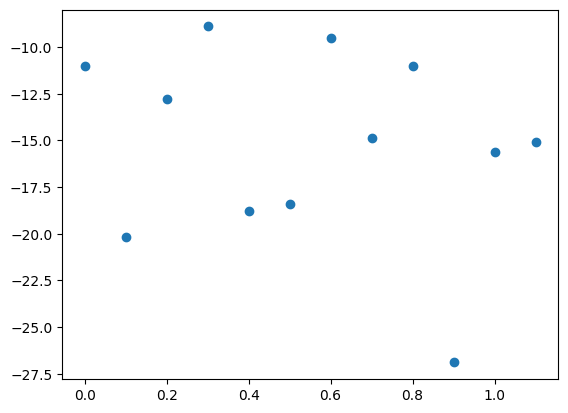

In [486]:
plt.scatter(X, Y)

In [487]:
def L_i(x, ind, table_x):
    res = 1
    for j in range(0, len(table_x)):
        if j != ind:
            res *= (x - table_x[j]) / (table_x[ind] - table_x[j])
    return res

In [488]:
def InterpolLag(x):
    global X, Y
    
    result = 0
    for i in range(0, len(X)):
        result += Y[i] * L_i(x, i, X)
    return result

Интерполяция полиномом Лагранжа
Данные:
[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5]
[-11.0, -20.2, -12.8, -8.9, -18.8, -18.4]


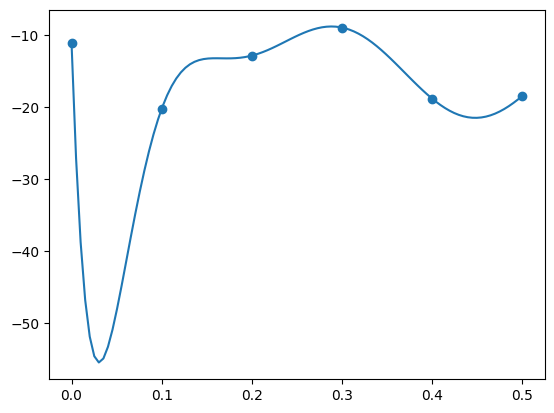

In [489]:
X_n = X[:6]
Y_n = Y[:6]


x = np.linspace(X_n[0], X_n[5], 100)
y = [InterpolLag(el) for el in x]


print("Интерполяция полиномом Лагранжа\nДанные:")
print(X_n, Y_n, sep='\n')
plt.plot(x, y)
plt.scatter(X_n, Y_n)

# 3
Для любого заданного столбца данных (кроме первого) и любых 6-ти последовательных строчек из массива
выполнить интерполяцию с помощью первой интерполяционной формулы Ньютона ($h = 0,1$), построить
график.

$$N_n(x) = y_0 + \frac{\Delta y_0}{h}(x - x_0) + \frac{\Delta^2 y_0}{2 h^2}(x - x_0)(x - x_1) + \cdots + \frac{\Delta^n y_0}{n! h^n}(x - x_0)(x - x_1)\cdot ... \cdot(x - x_{n - 1})$$

$$\Delta^k y_i = \sum\limits_{j = 0}^{k}(-1)^{k - j}C_k^iy_{i + j}$$

In [490]:
X_n = X[:6]
Y_n = Y[:6]

for i in range(len(X_n)):
    X_n[i] = round(X_n[i], 1)
    print(f'x, y: {X_n[i]}, {Y_n[i]}')

x, y: 0.0, -11.0
x, y: 0.1, -20.2
x, y: 0.2, -12.8
x, y: 0.3, -8.9
x, y: 0.4, -18.8
x, y: 0.5, -18.4


In [491]:
def k_coeff(ind, k):
    res = 1
    for j in range(ind):
        res *= k - j
        
    return res

In [492]:
def fact(a):
    res = 1
    for i in range(1, a + 1):
        res *= i
        
    return res

In [493]:
def x_coeff(x, ind):
    global X_n
    res = 1
    
    for i in range(ind):
        res *= x - X_n[i]
    return res

In [494]:
def C(m, n):
    return fact(n) / (fact(n - m) * fact(m))

In [495]:
def FiniteDifference(k):    
    res = 0
    for j in range(0, k + 1):
        res += np.pow(-1, k - j) * C(j, k) * Y_n[j]
    return res

In [496]:
def InterpolNewtonFK(x):
    result = Y_n[0]
    
    for i in range(1, len(X_n)):
        result += FiniteDifference(i) * x_coeff(x, i) / np.pow(H, i) / fact(i)
    return result
        

Интерполяция полиномом Лагранжа
Данные:
[0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
[-11.0, -20.2, -12.8, -8.9, -18.8, -18.4]


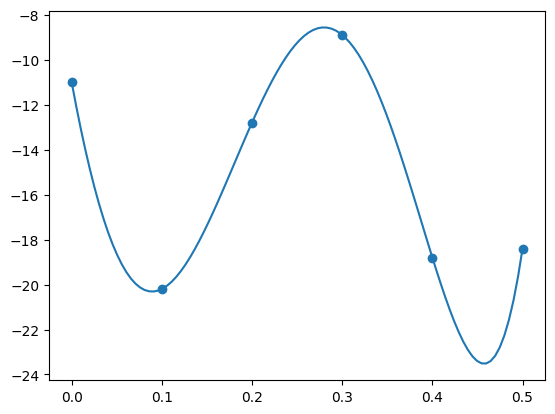

In [497]:
x_n = np.linspace(X_n[0], X_n[5], 100)
y_n = [InterpolNewtonFK(el) for el in x_n]


print("Интерполяция полиномом Лагранжа\nДанные:")
print(X_n, Y_n, sep='\n')
plt.plot(x_n, y_n)
plt.scatter(X_n, Y_n)

# 3
Для следующих 6-ти строчек из массива выполнить интерполяцию с помощью второй интерполяционной
формулы Ньютона (h = 0, 1), построить график.

In [498]:
n = len(Y_n) - 1

dy = MakeMatrix(n, n)

for i in range(n):
    dy[i][0] = Y_n[i + 1] - Y_n[i]
    
for i in range(1, n):
    for j in range(n - i):
        dy[j][i] = dy[j + 1][i - 1] - dy[j][i - 1]
dy

[[-9.2,
  16.599999999999998,
  -20.099999999999994,
  9.799999999999992,
  24.600000000000016],
 [7.399999999999999,
  -3.4999999999999982,
  -10.300000000000002,
  34.400000000000006,
  0],
 [3.9000000000000004, -13.8, 24.1, 0, 0],
 [-9.9, 10.300000000000002, 0, 0, 0],
 [0.40000000000000213, 0, 0, 0, 0]]

In [499]:
def InterpolNewtonSK(x):
    n = len(Y_n) - 1
    result = Y_n[n]
    
    q = (x - X_n[n]) / H
    mult = 1
    
    for i in range(n):
        mult *= q + i
        
        result += dy[n - i - 1][i] * mult / fact(i + 1)
    return result

Интерполяция полиномом Лагранжа(назад)
Данные:
[0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
[-11.0, -20.2, -12.8, -8.9, -18.8, -18.4]


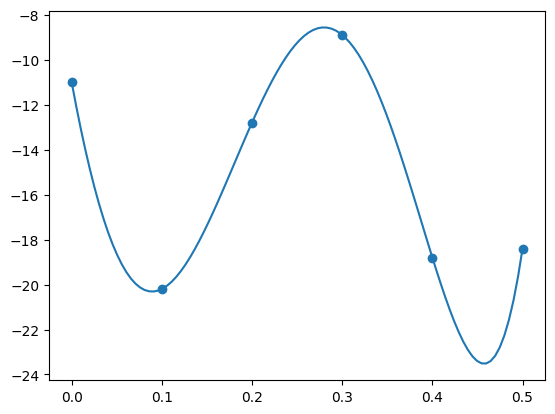

In [500]:
x_n = np.linspace(X_n[0], X_n[5], 100)
y_n = [InterpolNewtonSK(el) for el in x_n]


print("Интерполяция полиномом Лагранжа(назад)\nДанные:")
print(X_n, Y_n, sep='\n')
plt.plot(x_n, y_n)
plt.scatter(X_n, Y_n)

# 5
Для любого заданного столбца данных (кроме первого) и всех строчек массива, не содержащих недосто-
верные значения, выполнить аппроксимацию степенным полиномом (степень полинома – до 5), построить
график.

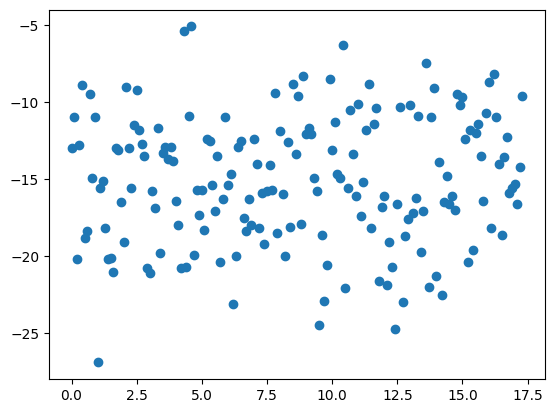

In [501]:
H = 0.1

Y_p = list(data[month])
X_p = [round(H * i, 1) for i in range(len(Y_p))]

plt.scatter(X_p, Y_p)

In [502]:
def MakeMatrix(n, m, value=0):
    res = []
    for i in range(n):
        res.append([])
        for j in range(m):
            res[i].append(value)
    return res

def MatrixMultiplication(A, B):
    result = MakeMatrix(len(A), len(B[0])) 
    #print(result)
    for i in range(len(A)):
        for j in range(len(B[0])):
            for k in range(len(A[0])):
                result[i][j] += A[i][k] * B[k][j]
    return result

In [503]:
def XMatrix(N_):
    X = np.zeros((N_ + 1, N_ + 1))
    
    for i in range(N_ + 1):
        for j in range(N_ + 1):
            elem = 0
            for k in range(len(X_p)):
                elem += X_p[k]**(i + j)
            X[i][j] = elem
    return X

In [504]:
def XYMatrix(N_):
    XY = np.zeros((N_ + 1, 1))
    
    for i in range(N_ + 1):
        for k in range(len(X_p)):
            XY[i][0] += Y_p[k] * X_p[k]**i
    return XY

In [505]:
n_ = len(Y_p)
N = 5

In [506]:
X_matr = XMatrix(N)

Y_matr = XYMatrix(N)

X_matr, Y_matr, len(X_matr)

(array([[1.74000000e+02, 1.50510000e+03, 1.74089900e+04, 2.26532601e+05,
         3.14423768e+06, 4.54598073e+07],
        [1.50510000e+03, 1.74089900e+04, 2.26532601e+05, 3.14423768e+06,
         4.54598073e+07, 6.76041047e+08],
        [1.74089900e+04, 2.26532601e+05, 3.14423768e+06, 4.54598073e+07,
         6.76041047e+08, 1.02629493e+10],
        [2.26532601e+05, 3.14423768e+06, 4.54598073e+07, 6.76041047e+08,
         1.02629493e+10, 1.58273979e+11],
        [3.14423768e+06, 4.54598073e+07, 6.76041047e+08, 1.02629493e+10,
         1.58273979e+11, 2.47138660e+12],
        [4.54598073e+07, 6.76041047e+08, 1.02629493e+10, 1.58273979e+11,
         2.47138660e+12, 3.89794278e+13]]),
 array([[-2.62680000e+03],
        [-2.25023300e+04],
        [-2.57926847e+05],
        [-3.32777151e+06],
        [-4.58196712e+07],
        [-6.57570506e+08]]),
 6)

In [507]:
polinom_coeff = np.linalg.solve(X_matr , Y_matr)
polinom_coeff

array([[-1.44914289e+01],
       [-1.27913093e+00],
       [ 4.82888424e-01],
       [-6.80695073e-02],
       [ 3.96362167e-03],
       [-7.98348575e-05]])

In [508]:
x = np.linspace(X_p[0], X_p[n_ - 1], 100)
y = [0] * len(x)

for i in range(len(x)):
    el = 0
    for n in range(N + 1):
        el += polinom_coeff[n][0] * x[i]**n
    #print(el)
    y[i] = el
    

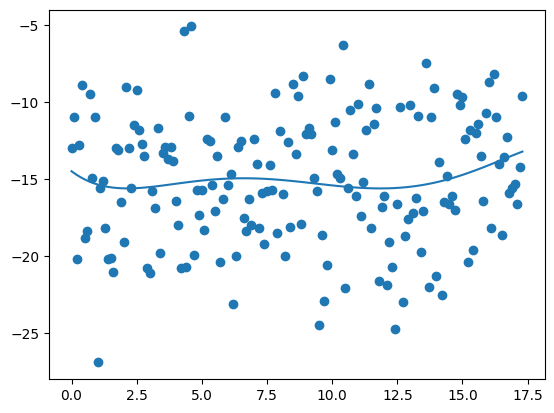

In [509]:
plt.plot(x, y)
plt.scatter(X_p, Y_p)